In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import random
from collections import deque
from tqdm import tqdm
import pandas as pd
import copy
import collections

In [2]:
def P_0_matrix(x):
    P_0_matrix=np.array([[x,0,0,1-x],
                   [1-x,x,0,0],
                   [0,1-x,x,0],
                   [0,0,1-x,x]])  
    return P_0_matrix

In [3]:
def P_1_matrix(x):
    P_0_matrix=np.array([[x,0,0,1-x],
                   [1-x,x,0,0],
                   [0,1-x,x,0],
                   [0,0,1-x,x]])  
    return P_0_matrix.transpose()

In [4]:
P_1_matrix(0.9)

array([[0.9, 0.1, 0. , 0. ],
       [0. , 0.9, 0.1, 0. ],
       [0. , 0. , 0.9, 0.1],
       [0.1, 0. , 0. , 0.9]])

In [5]:
action_space=[0,1]
state_space=[0,1,2,3]
reward_matrix=[[-1,-1],[0,0],[0,0],[1,1]]

In [6]:
def step(state,state_space,action,P_0_matrix,P_1_matrix,reward_matrix):
  if(action==1):
    new_state=np.random.choice(state_space,replace=True,p=P_1_matrix[state])
    reward=reward_matrix[state][1]
  else:
    new_state=np.random.choice(state_space,replace=True,p=P_0_matrix[state])
    reward=reward_matrix[state][0]
  return [new_state,reward]

In [7]:
temp=[]
for i in range(100):
    new_state=np.random.choice(state_space,replace=True,p=P_1_matrix(0.9)[2])
    temp.append(new_state)

<BarContainer object of 2 artists>

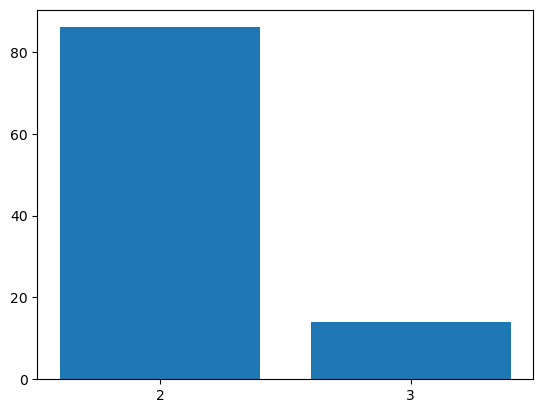

In [8]:
freq=collections.Counter(temp)
names = list(freq.keys())
values = list(freq.values())

plt.bar(range(len(freq)), values, tick_label=names)

In [9]:
N=10
M=2
epsilon=0.1
arm_indexes=[i for i in range(N)]


In [10]:
Q_values=[]
for i in range(0,N):
  Q_values.append(copy.deepcopy(reward_matrix))
  #Q_values.append([[0,0],[0,0],[0,0],[0,0]])
  
Q_values

[[[-1, -1], [0, 0], [0, 0], [1, 1]],
 [[-1, -1], [0, 0], [0, 0], [1, 1]],
 [[-1, -1], [0, 0], [0, 0], [1, 1]],
 [[-1, -1], [0, 0], [0, 0], [1, 1]],
 [[-1, -1], [0, 0], [0, 0], [1, 1]],
 [[-1, -1], [0, 0], [0, 0], [1, 1]],
 [[-1, -1], [0, 0], [0, 0], [1, 1]],
 [[-1, -1], [0, 0], [0, 0], [1, 1]],
 [[-1, -1], [0, 0], [0, 0], [1, 1]],
 [[-1, -1], [0, 0], [0, 0], [1, 1]]]

In [11]:
def Q_value_update(Q_values,state,next_state,action,reward,arm_index,whittle_index,alpha):
  # if action==1:
  #   Q_values[arm_index][state][action]=(1-alpha)*(Q_values[arm_index][state][action])+alpha*(reward+max(Q_values[arm_index][next_state])-(np.array(Q_values[arm_index]).sum())/8)
  #   return Q_values

  # else:
  #   Q_values[arm_index][state][action]=(1-alpha)*(Q_values[arm_index][state][action])+alpha*(reward+whittle_index+max(Q_values[arm_index][next_state])-(np.array(Q_values[arm_index]).sum())/8)
  #   return Q_values
  Q_values[arm_index][state][action]=(1-alpha)*(Q_values[arm_index][state][action])+alpha*(reward+(1-action)*whittle_index+max(Q_values[arm_index][next_state])-(np.array(Q_values[arm_index]).sum())/8)
  return Q_values

In [12]:
def act(Q_values,epsilon,state,arm_index):
  decision=np.random.binomial(n=1,p=epsilon,size=1)
  if decision==1:
    action=random.choice([0,1])
  else:
    action=np.argmax(Q_values[arm_index][state])
  return action

In [13]:
current_state=[random.choice([0,1,2,3]) for _ in range(N)]  


In [14]:
whittle_indexes=[]
for _ in range(N):
    whittle_indexes.append([0 for _ in range(len(state_space))])
whittle_indexes

[[0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0]]

In [15]:
# whittle_indexes=[[-0.5,0.5,1,-1]]

In [16]:
rewards=[]
subsidies=[]
action_sums=[]
betas=[]
alphas=[]
epsilon=1
whittle_indexes_over_time=[]
whittle_indexes_over_time.append(copy.deepcopy(whittle_indexes))
whittle_indexes_over_time

[[[0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0]]]

In [17]:
random.choices(arm_indexes,k=M)

[1, 3]

In [18]:
arm_indexes

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [19]:
Q_values[4][2][1]

0

In [20]:
state_space

[0, 1, 2, 3]

In [21]:
def whittle_indexes_update(whittle_indexes,Q_values,beta,arm_indexes,state_space,print_output=False):
    for i in arm_indexes:
        for j in state_space:
            whittle_indexes[i][j]+=beta*(Q_values[i][j][1]-Q_values[i][j][0])
            if print_output==True:
                print(i)
                print(j)
                print(Q_values[i][j][1]-Q_values[i][j][0])
    return whittle_indexes
    

In [22]:
def get_indices_to_pull(epsilon,whittle_indexes,arm_indexes,M,current_state):
    decision=np.random.binomial(n=1,p=epsilon,size=1)
    whittle_index_arms=[0 for _ in range(len(arm_indexes))]
    if decision==1:
        indices_to_pull=random.choices(arm_indexes,k=M)
    else:
        for index in arm_indexes:
            # print(index)
            whittle_index_arms[index]=whittle_indexes[index][current_state[index]]
        #print(whittle_index_arms)
        indices_to_pull = sorted(range(len(whittle_index_arms)), key = lambda j: whittle_index_arms[j])[-M:]
    return indices_to_pull


In [23]:
beta=1/(1+np.ceil(10000*np.log(10000)/500))
beta

0.005376344086021506

In [24]:
# for i in range(1,500001):
#   action_sum=0
#   reward_sum=0
#   T=False
#   alpha=1/np.ceil(1+i/5000)
#   # if(i<50000):
#   #   beta=0
#   # else:
#   if i%50==0:
#     beta=1/(1+np.ceil((i)*np.log(i)/5000))
#   else:
#     beta=0
#   temp=0
#   reward=0
#   new_state=0
#   epsilon=0.1
#   indices_to_pull=get_indices_to_pull(epsilon,whittle_indexes,arm_indexes,M,current_state)
#   # print(indices_to_pull)
#   # if(i==50000):
#   #   print(Q_values)
#   #   T=True
#   for index in arm_indexes:
#       # temp=copy.deepcopy(Q_values)
#       if index in indices_to_pull:
#         # print(i)
#         # print(alpha)
#         # print(beta)
#         # action=np.argmax(Q_values[index][current_state[index]])
#         action=1
#         # print(current_state)
#         # print(action)

#         action_sum+=action
#         x=step(current_state[index],state_space,action,P_0_matrix(0.5),P_1_matrix(0.5),reward_matrix)
#         new_state=x[0]
#         # print(new_state)
#         reward=x[1]
#         # print(reward)

        
#         Q_values=Q_value_update(Q_values,current_state[index],new_state,action,reward,index,whittle_indexes[index][current_state[index]],alpha)
#         # print(Q_values)
#         # whittle_indexes[index][current_state[index]]+=beta*temp


#         # print(whittle_indexes)
#         # print("--")
#         current_state[index]=new_state
#         reward_sum+=reward

#         #print(x)
#       else:
#         # print(i)
#         # print(alpha)
#         # print(beta)
#         # action=np.argmax(Q_values[index][current_state[index]])
#         action=0
#         # print(current_state)
#         # print(action)

#         action_sum+=action
#         x=step(current_state[index],state_space,action,P_0_matrix(0.5),P_1_matrix(0.5),reward_matrix)
#         new_state=x[0]
#         # print(new_state)
#         reward=x[1]
#         # print(reward)

#         Q_values=Q_value_update(Q_values,current_state[index],new_state,action,reward,index,whittle_indexes[index][current_state[index]],alpha)
#         # print(Q_values)
#         # whittle_indexes[index][current_state[index]]+=beta*temp

#         # print(whittle_indexes)
#         # print("--")
#         current_state[index]=new_state
#         reward_sum+=reward

#         #print(x)
#   # print(i)
#   # print(whittle_indexes)
#   # print(current_state[index])
#   # print(Q_values[index][current_state[index]][1])
#   # print(Q_values[index][current_state[index]][0])
#   # print((Q_values[index][current_state[index]][1]-Q_values[index][current_state[index]][0]))
#   # print('----')
#   whittle_indexes=whittle_indexes_update(whittle_indexes,Q_values,beta,arm_indexes,state_space,T)

#   whittle_indexes_over_time.append(copy.deepcopy(whittle_indexes))

#   # epsilon=epsilon*gamma
#   if epsilon<=0.1:
#     epsilon=0.1
#   rewards.append(reward_sum)
#   action_sums.append(action_sum)
#   betas.append(beta)
#   alphas.append(alpha)








In [25]:
Q1=[[-1,-1],[0,0],[0,0],[1,1]]
Q2=[[-1,-1],[0,0],[0,0],[1,1]]
Q3=[[-1,-1],[0,0],[0,0],[1,1]]
Q4=[[-1,-1],[0,0],[0,0],[1,1]]
w1=0
w2=0
w3=0
w4=0

In [26]:
random.random()

0.6040761620889403

In [27]:
w_overtime=[]

In [28]:
for i in range(1,500001):
  action_sum=0
  reward_sum=0
  T=False
  alpha=1/np.ceil(1+i/5000)
  # if(i<50000):
  #   beta=0
  # else:
  if i%50==0:
    beta=1/(1+np.ceil((i)*np.log(i)/5000))
  else:
    beta=0
  temp=0
  reward=0
  new_state=0
  epsilon=0.1
  whittle_index_arms=[]
  for i in range(N):
    if current_state[i]==0:
      whittle_index_arms.append(w1)
    elif current_state[i]==1:
      whittle_index_arms.append(w2)
    elif current_state[i]==2:
      whittle_index_arms.append(w3)
    else:
      whittle_index_arms.append(w4)

  # indices_to_pull=get_indices_to_pull(epsilon,whittle_indexes,arm_indexes,M,current_state)
  if random.random()>0.1:
    indices_to_pull = sorted(range(len(whittle_index_arms)), key = lambda j: whittle_index_arms[j])[-M:]
  else:
    indices_to_pull=random.choices(arm_indexes,k=M)
  # print(indices_to_pull)
  # if(i==50000):
  #   print(Q_values)
  #   T=True
  for index in arm_indexes:
      # temp=copy.deepcopy(Q_values)
      if index in indices_to_pull:
        # print(i)
        # print(alpha)
        # print(beta)
        # action=np.argmax(Q_values[index][current_state[index]])
        action=1
        # print(current_state)
        # print(action)

        action_sum+=action
        x=step(current_state[index],state_space,action,P_0_matrix(0.6),P_1_matrix(0.6),reward_matrix)
        new_state=x[0]
        # print(new_state)
        reward=x[1]
        # print(reward)
        Q1[current_state[index]][action]=(1-alpha)*(Q1[current_state[index]][action])+alpha*(reward+max(Q1[new_state])-(np.array(Q1).sum())/8)
        Q2[current_state[index]][action]=(1-alpha)*(Q2[current_state[index]][action])+alpha*(reward+max(Q2[new_state])-(np.array(Q2).sum())/8)
        Q3[current_state[index]][action]=(1-alpha)*(Q3[current_state[index]][action])+alpha*(reward+max(Q3[new_state])-(np.array(Q3).sum())/8)
        Q4[current_state[index]][action]=(1-alpha)*(Q4[current_state[index]][action])+alpha*(reward+max(Q4[new_state])-(np.array(Q4).sum())/8)


        
        # Q_values=Q_value_update(Q_values,current_state[index],new_state,action,reward,index,whittle_indexes[index][current_state[index]],alpha)
        # print(Q_values)
        # whittle_indexes[index][current_state[index]]+=beta*temp


        # print(whittle_indexes)
        # print("--")
        current_state[index]=new_state
        reward_sum+=reward

        #print(x)
      else:
        # print(i)
        # print(alpha)
        # print(beta)
        # action=np.argmax(Q_values[index][current_state[index]])
        action=0
        # print(current_state)
        # print(action)

        action_sum+=action
        x=step(current_state[index],state_space,action,P_0_matrix(0.6),P_1_matrix(0.6),reward_matrix)
        new_state=x[0]
        # print(new_state)
        reward=x[1]
        # print(reward)
        Q1[current_state[index]][action]=(1-alpha)*(Q1[current_state[index]][action])+alpha*(reward+w1+max(Q1[new_state])-(np.array(Q1).sum())/8)
        Q2[current_state[index]][action]=(1-alpha)*(Q2[current_state[index]][action])+alpha*(reward+w2+max(Q2[new_state])-(np.array(Q2).sum())/8)
        Q3[current_state[index]][action]=(1-alpha)*(Q3[current_state[index]][action])+alpha*(reward+w3+max(Q3[new_state])-(np.array(Q3).sum())/8)
        Q4[current_state[index]][action]=(1-alpha)*(Q4[current_state[index]][action])+alpha*(reward+w4+max(Q4[new_state])-(np.array(Q4).sum())/8)

        
        # print(Q_values)
        # whittle_indexes[index][current_state[index]]+=beta*temp

        # print(whittle_indexes)
        # print("--")
        current_state[index]=new_state
        reward_sum+=reward

        #print(x)
  # print(i)
  # print(whittle_indexes)
  # print(current_state[index])
  # print(Q_values[index][current_state[index]][1])
  # print(Q_values[index][current_state[index]][0])
  # print((Q_values[index][current_state[index]][1]-Q_values[index][current_state[index]][0]))
  # print('----')
  # whittle_indexes=whittle_indexes_update(whittle_indexes,Q_values,beta,arm_indexes,state_space,T)
  w1=w1+beta*(Q1[0][1]-Q1[0][0])
  w2=w2+beta*(Q2[1][1]-Q2[1][0])
  w3=w3+beta*(Q3[2][1]-Q3[2][0])
  w4=w4+beta*(Q4[3][1]-Q4[3][0])
  # whittle_indexes_over_time.append(copy.deepcopy(whittle_indexes))
  w_overtime.append([w1,w2,w3,w4])
  # epsilon=epsilon*gamma
  if epsilon<=0.1:
    epsilon=0.1
  rewards.append(reward_sum)
  action_sums.append(action_sum)
  betas.append(beta)
  alphas.append(alpha)








In [29]:
w4

-0.9977360539485535

In [30]:
# for i in range(1,1000001):
#   action_sum=0
#   reward_sum=0
#   alpha=1/(1+(i/5000))
#   beta=0
#   # # if i<50000:
#   # #   beta=0
#   # # else:
#   # if i%50==0:
#   #   beta=1/(1+np.ceil(i*np.log(i)/5000))
#   # else:
#   #   beta=0

#   epsilon=0.1
#   for index in arm_indexes:
#       # action=np.argmax(Q_values[index][current_state[index]])
#       action=act(Q_values,epsilon,current_state[index],index)
#       action_sum+=action
#       x=step(current_state[index],state_space,action,P_0_matrix(0.5),P_1_matrix(0.5),reward_matrix)
#       new_state=x[0]
#       reward=x[1]
#       temp=Q_values[index][current_state[index]][1]-Q_values[index][current_state[index]][0]
#       Q_value_update(Q_values,current_state[index],new_state,action,reward,index,whittle_indexes[index][current_state[index]],alpha)
      
#       # whittle_indexes[index][current_state[index]]+=beta*temp
#       current_state[index]=new_state
#       reward_sum+=reward
#       #print(x)
#   # print(i)
#   # print(whittle_indexes)
#   # print(current_state[index])
#   # print(Q_values[index][current_state[index]][1])
#   # print(Q_values[index][current_state[index]][0])
#   # print((Q_values[index][current_state[index]][1]-Q_values[index][current_state[index]][0]))
#   # print('----')

#   # whittle_indexes_over_time.append(copy.deepcopy(whittle_indexes))

#   # epsilon=epsilon*gamma
#   # if epsilon<=0.01:
#   #   epsilon=0.01
#   rewards.append(reward_sum)
#   action_sums.append(action_sum)
#   betas.append(beta)
#   alphas.append(alpha)








In [31]:
# Q_values[1]

In [32]:
# whittle_indexes

In [33]:
alpha=1/(1+np.ceil(700/500))
alpha

0.3333333333333333

In [34]:
# new_state,reward=step(current_state[1],state_space,1,P_0_matrix(0.5),P_1_matrix(0.5),reward_matrix)

In [35]:
# for i in range(1,500001):
#   action_sum=0
#   reward_sum=0
#   alpha=1/(1+(i/500))
  
#   if i<100000:
#     beta=0
#   else:
#     if i%50==0:
#       beta=1/(1+np.ceil(i*np.log(i)/500))
#     else:
#       beta=0

#   epsilon=0.1
#   if i==100000:
#     print(Q_values)
#   for index in arm_indexes:
#       # action=np.argmax(Q_values[index][current_state[index]])
#       action=act(Q_values,epsilon,current_state[index],index)
#       action_sum+=action
#       new_state,reward=step(current_state[index],state_space,action,P_0_matrix(0.5),P_1_matrix(0.5),reward_matrix)
      
#       temp=copy.deepcopy(Q_values)
      
#       Q_values=Q_value_update(Q_values,current_state[index],new_state,action,reward,index,whittle_indexes[index][current_state[index]],alpha)
#       whittle_indexes=whittle_indexes_update(whittle_indexes,temp,beta,arm_indexes,state_space)
#       current_state[index]=new_state
#       reward_sum+=reward
#       #print(x)
#   # print(i)
#   # print(whittle_indexes)
#   # print(current_state[index])
#   # print(Q_values[index][current_state[index]][1])
#   # print(Q_values[index][current_state[index]][0])
#   # print((Q_values[index][current_state[index]][1]-Q_values[index][current_state[index]][0]))
#   # print('----')

#   whittle_indexes_over_time.append(copy.deepcopy(whittle_indexes))

#   # epsilon=epsilon*gamma
#   # if epsilon<=0.01:
#   #   epsilon=0.01
#   rewards.append(reward_sum)
#   action_sums.append(action_sum)
#   betas.append(beta)
#   alphas.append(alpha)








In [36]:
# Q_values[0]

In [37]:
# whittle_indexes_over_time[50000][0]

In [38]:
# whittle_indexes_over_time[200][2]

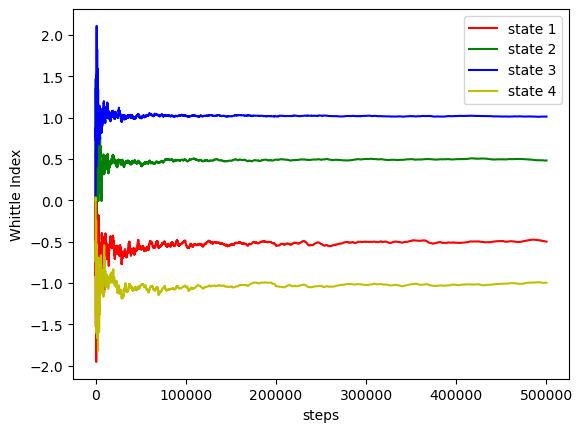

In [39]:
t=500000
j=0
state1=[w_overtime[i][0] for i in range(t)]
state2=[w_overtime[i][1] for i in range(t)]
state3=[w_overtime[i][2] for i in range(t)]
state4=[w_overtime[i][3] for i in range(t)]
plt.figure()
plt.plot(state1,color='r',label='state 1')
plt.plot(state2,color='g',label='state 2')
plt.plot(state3,color='b',label='state 3')
plt.plot(state4,color='y',label='state 4')
plt.legend()
plt.ylabel('Whittle Index')
plt.xlabel('steps')
# plt.ylim([-2,2])
plt.show()

In [40]:
w_overtime[500000-1]

[-0.5001294906177783,
 0.4814523837490677,
 1.012279674619874,
 -0.9977360539485535]

In [41]:
# t=500000
# j=0
# state1=[whittle_indexes_over_time[i][j][0] for i in range(t)]
# state2=[whittle_indexes_over_time[i][j][1] for i in range(t)]
# state3=[whittle_indexes_over_time[i][j][2] for i in range(t)]
# state4=[whittle_indexes_over_time[i][j][3] for i in range(t)]
# plt.figure()
# plt.plot(state1,color='r',label='state 1')
# plt.plot(state2,color='g',label='state 2')
# plt.plot(state3,color='b',label='state 3')
# plt.plot(state4,color='y',label='state 4')
# plt.legend()
# plt.ylabel('Whittle Index')
# plt.xlabel('steps')
# # plt.ylim([-2,2])
# plt.show()